In [1]:

!pip install torch torchvision -q

In [2]:
import numpy as np

np.random.seed(42)

GRID_H, GRID_W = 32, 32
HOURS = 720
CHANNELS = 5

# Road mask - Baku main roads
road_mask = np.zeros((GRID_H, GRID_W), dtype=np.float32)
road_mask[8, 4:28] = 1.0     # Neftchilar ave
road_mask[14, 2:30] = 1.0    # Babek ave
road_mask[20, 6:26] = 1.0    # Tbilisi ave
road_mask[25, 3:29] = 1.0    # Z.Bunyadov ave
road_mask[5:28, 10] = 1.0    # Nizami st
road_mask[5:28, 18] = 1.0    # H.Aliyev st
road_mask[3:30, 24] = 1.0    # Heydar Aliyev ave
road_mask[12, 8:22] = 0.6
road_mask[17, 10:25] = 0.6
road_mask[5:25, 15] = 0.6

# Intersection hotspots
hotspots = [(8,10),(8,18),(8,24),(14,10),(14,18),(14,24),(20,10),(20,18),(25,10),(25,18),(25,24)]
for (r,c) in hotspots:
    road_mask[max(0,r-1):r+2, max(0,c-1):c+2] = 1.0

# Generate data
data = np.zeros((HOURS, CHANNELS, GRID_H, GRID_W), dtype=np.float32)

for t in range(HOURS):
    hour = t % 24
    dow = (t // 24) % 7

    if 7 <= hour <= 9: base = 0.75
    elif 17 <= hour <= 19: base = 0.85
    elif 12 <= hour <= 14: base = 0.5
    elif 22 <= hour or hour <= 5: base = 0.05
    else: base = 0.35

    if dow >= 5: base *= 0.6

    density = base * road_mask + np.random.normal(0, 0.05, (GRID_H, GRID_W))
    for (r,c) in hotspots:
        density[max(0,r-1):r+2, max(0,c-1):c+2] += base * 0.3 * np.random.uniform(0.5, 1.5)
    density = np.clip(density, 0, 1)
    data[t, 0] = density

    rain_day = (t // 24) % 5 == 0
    if rain_day:
        data[t, 1] = np.clip(np.random.uniform(0.3, 0.8) + np.random.normal(0, 0.1, (GRID_H, GRID_W)), 0, 1)
        data[t, 0] = np.clip(data[t, 0] * 1.3, 0, 1)
    else:
        data[t, 1] = np.clip(np.random.uniform(0, 0.05, (GRID_H, GRID_W)), 0, 1)

    data[t, 2] = hour / 23.0
    data[t, 3] = 1.0 if (dow >= 5 or (t//24) in [10,20]) else 0.0
    data[t, 4] = road_mask

print(f"Data ready! Shape: {data.shape}")
print(f"Peak hour avg: {data[17::24, 0].mean():.3f}")
print(f"Night avg: {data[1::24, 0].mean():.3f}")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
import os
save_path = '/content/drive/MyDrive/traffic_project'
os.makedirs(save_path, exist_ok=True)

np.save(f'{save_path}/baku_grid_data.npy', data)
np.save(f'{save_path}/road_mask.npy', road_mask)
np.save(f'{save_path}/hotspots.npy', np.array(hotspots))

print(f"Saved to Google Drive! Size: {data.nbytes / 1024 / 1024:.1f} MB")

Data ready! Shape: (720, 5, 32, 32)
Peak hour avg: 0.201
Night avg: 0.029
Mounted at /content/drive
Saved to Google Drive! Size: 14.1 MB


Shape: (720, 5, 32, 32)


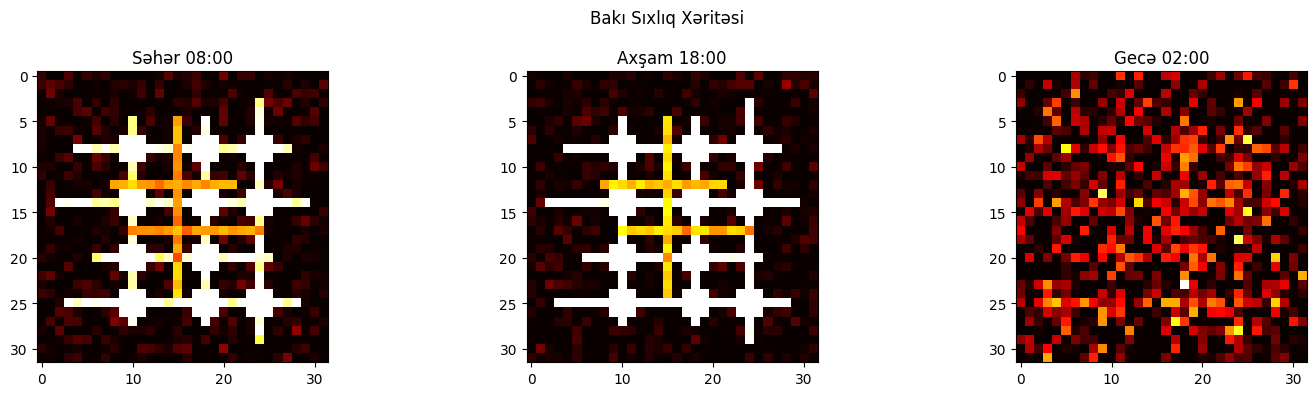

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('/content/drive/MyDrive/traffic_project/baku_grid_data.npy')
print("Shape:", data.shape)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(data[8, 0], cmap='hot')
axes[0].set_title("Səhər 08:00")

axes[1].imshow(data[18, 0], cmap='hot')
axes[1].set_title("Axşam 18:00")

axes[2].imshow(data[2, 0], cmap='hot')
axes[2].set_title("Gecə 02:00")

plt.suptitle("Bakı Sıxlıq Xəritəsi")
plt.tight_layout()
plt.show()

In [4]:
# Step 2: Create sliding window sequences
# Input: 6 hours -> Output: 3 hours (density channel only)

SEQ_IN = 6
SEQ_OUT = 3

X, Y = [], []

for i in range(HOURS - SEQ_IN - SEQ_OUT + 1):
    X.append(data[i : i + SEQ_IN])                    # (6, 5, 32, 32)
    Y.append(data[i + SEQ_IN : i + SEQ_IN + SEQ_OUT, 0])  # (3, 32, 32) density only

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

# Train/val/test split
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, Y_train = X[:train_end], Y[:train_end]
X_val, Y_val = X[train_end:val_end], Y[train_end:val_end]
X_test, Y_test = X[val_end:], Y[val_end:]

print(f"Total samples: {n}")
print(f"X shape: {X.shape} -> (samples, 6 hours, 5 channels, 32, 32)")
print(f"Y shape: {Y.shape} -> (samples, 3 hours, 32, 32)")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Total samples: 712
X shape: (712, 6, 5, 32, 32) -> (samples, 6 hours, 5 channels, 32, 32)
Y shape: (712, 3, 32, 32) -> (samples, 3 hours, 32, 32)
Train: 498 | Val: 107 | Test: 107


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, kernel=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, kernel, padding=kernel//2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = gates.chunk(4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        c = f * c + i * torch.tanh(g)
        h = o * torch.tanh(c)
        return h, c

class TrafficPredictor(nn.Module):
    def __init__(self, in_ch=5, hid1=64, hid2=32, out_steps=3):
        super().__init__()
        self.hid1, self.hid2 = hid1, hid2
        self.out_steps = out_steps
        self.cell1 = ConvLSTMCell(in_ch, hid1)
        self.cell2 = ConvLSTMCell(hid1, hid2)
        self.output = nn.Conv2d(hid2, 1, kernel_size=1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        h1 = torch.zeros(B, self.hid1, H, W, device=x.device)
        c1 = torch.zeros_like(h1)
        h2 = torch.zeros(B, self.hid2, H, W, device=x.device)
        c2 = torch.zeros_like(h2)

        for t in range(T):
            h1, c1 = self.cell1(x[:, t], h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)

        preds = []
        for _ in range(self.out_steps):
            preds.append(self.output(h2).squeeze(1))
        return torch.stack(preds, dim=1)  # (B, 3, 32, 32)

model = TrafficPredictor().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready! Parameters: {total_params:,}")

Device: cuda
Model ready! Parameters: 269,985


In [6]:
# Training
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(Y_val))
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=16)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(50):
    model.train()
    train_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += loss_fn(model(xb), yb).item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Train: {train_loss/len(train_dl):.5f} | Val: {val_loss/len(val_dl):.5f}")

print("Training done!")

Epoch 10/50 | Train: 0.00918 | Val: 0.00922
Epoch 20/50 | Train: 0.00670 | Val: 0.00721
Epoch 30/50 | Train: 0.00635 | Val: 0.00688
Epoch 40/50 | Train: 0.00609 | Val: 0.00677
Epoch 50/50 | Train: 0.00611 | Val: 0.00668
Training done!


+1h: 4 congestion zones detected
  Zone 1: center=(11,22), size=63, intensity=0.31
  Zone 2: center=(8,9), size=21, intensity=0.30
  Zone 3: center=(14,9), size=20, intensity=0.31
  Zone 4: center=(23,16), size=91, intensity=0.30
+2h: 4 congestion zones detected
  Zone 1: center=(11,22), size=63, intensity=0.31
  Zone 2: center=(8,9), size=21, intensity=0.30
  Zone 3: center=(14,9), size=20, intensity=0.31
  Zone 4: center=(23,16), size=91, intensity=0.30
+3h: 4 congestion zones detected
  Zone 1: center=(11,22), size=63, intensity=0.31
  Zone 2: center=(8,9), size=21, intensity=0.30
  Zone 3: center=(14,9), size=20, intensity=0.31
  Zone 4: center=(23,16), size=91, intensity=0.30


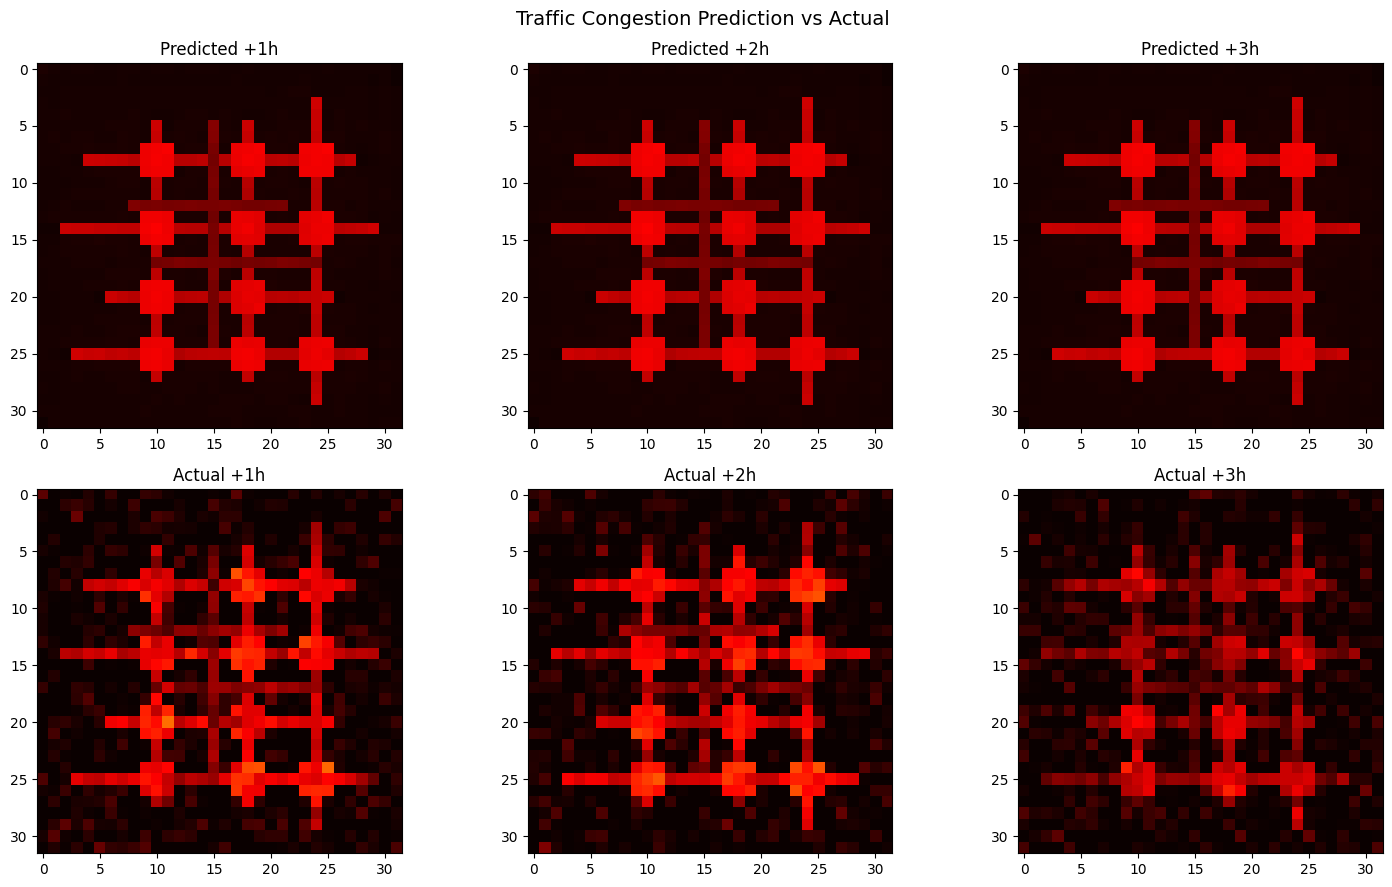

In [9]:
# Step 4: Predict and extract congestion zones
import matplotlib.pyplot as plt
from scipy import ndimage

# Take a test sample
sample_idx = 50
x_sample = torch.tensor(X_test[sample_idx:sample_idx+1]).to(device)

model.eval()
with torch.no_grad():
    pred = model(x_sample).cpu().numpy()[0]  # (3, 32, 32)

actual = Y_test[sample_idx]  # (3, 32, 32)

# Extract congestion zones
THRESHOLD = 0.2

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for t in range(3):
    # Predicted heatmap
    axes[0, t].imshow(pred[t], cmap='hot', vmin=0, vmax=1)
    axes[0, t].set_title(f'Predicted +{t+1}h')

    # Actual heatmap
    axes[1, t].imshow(actual[t], cmap='hot', vmin=0, vmax=1)
    axes[1, t].set_title(f'Actual +{t+1}h')

    # Find congestion clusters
    binary = (pred[t] > THRESHOLD).astype(int)
    labeled, num_zones = ndimage.label(binary)
    print(f"+{t+1}h: {num_zones} congestion zones detected")

    for zone_id in range(1, num_zones + 1):
        zone = (labeled == zone_id)
        rows, cols = np.where(zone)
        center_r, center_c = rows.mean(), cols.mean()
        size = zone.sum()
        intensity = pred[t][zone].mean()
        print(f"  Zone {zone_id}: center=({center_r:.0f},{center_c:.0f}), size={size}, intensity={intensity:.2f}")

plt.suptitle('Traffic Congestion Prediction vs Actual', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
print(f"Predicted min: {pred.min():.3f}, max: {pred.max():.3f}, mean: {pred.mean():.3f}")
print(f"Actual min: {actual.min():.3f}, max: {actual.max():.3f}, mean: {actual.mean():.3f}")

Predicted min: 0.008, max: 0.361, mean: 0.083
Actual min: 0.000, max: 0.528, mean: 0.081


/tmp/ipykernel_2452/93605809.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


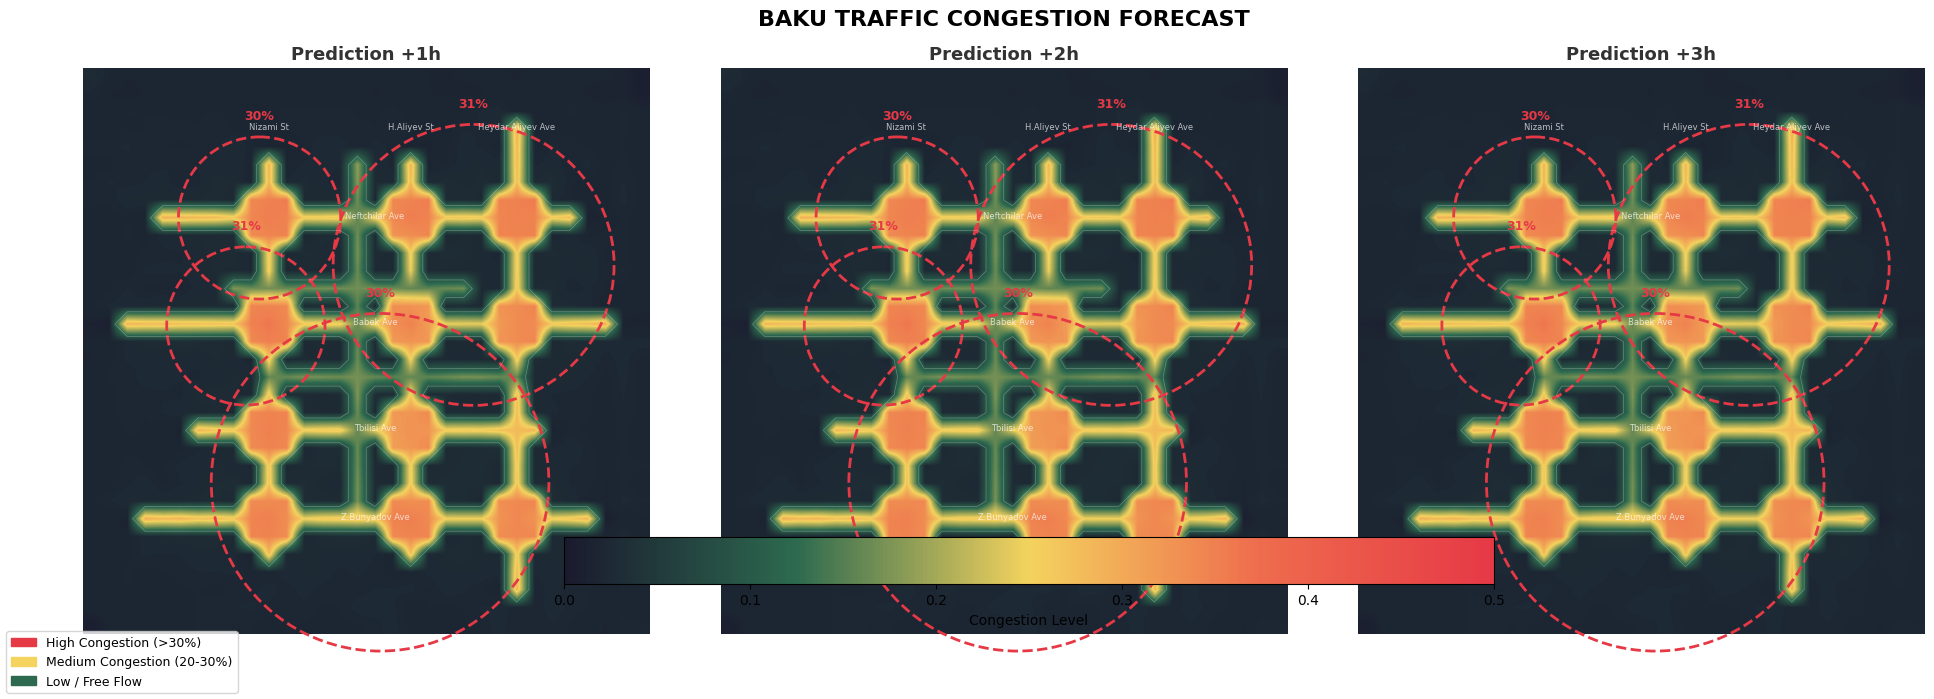

Saved to Drive!


In [10]:
# Step 5: Baku map overlay visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# Baku road names mapped to grid
road_labels = {
    (8, 16): "Neftchilar Ave",
    (14, 16): "Babek Ave",
    (20, 16): "Tbilisi Ave",
    (25, 16): "Z.Bunyadov Ave",
    (3, 10): "Nizami St",
    (3, 18): "H.Aliyev St",
    (3, 24): "Heydar Aliyev Ave",
}

# Custom green-yellow-red colormap
colors = ['#1a1a2e', '#2d6a4f', '#f4d35e', '#ee6c4d', '#e63946']
cmap = LinearSegmentedColormap.from_list('traffic', colors, N=256)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
hours_label = ["+1h", "+2h", "+3h"]

for t in range(3):
    ax = axes[t]
    im = ax.imshow(pred[t], cmap=cmap, vmin=0, vmax=0.5, interpolation='bilinear')

    # Draw road mask outline
    ax.contour(road_mask, levels=[0.3], colors='white', linewidths=0.5, alpha=0.3)

    # Mark congestion zones with circles
    binary = (pred[t] > 0.2).astype(int)
    labeled, num = ndimage.label(binary)
    for zid in range(1, num + 1):
        rows, cols = np.where(labeled == zid)
        cr, cc = rows.mean(), cols.mean()
        size = (labeled == zid).sum()
        intensity = pred[t][labeled == zid].mean()

        color = '#e63946' if intensity > 0.3 else '#f4d35e'
        circle = plt.Circle((cc, cr), radius=max(2, size**0.5), fill=False,
                           color=color, linewidth=2, linestyle='--')
        ax.add_patch(circle)
        ax.text(cc, cr - max(2, size**0.5) - 1, f'{intensity:.0%}',
               color=color, fontsize=9, ha='center', fontweight='bold')

    # Road labels
    for (r, c), name in road_labels.items():
        ax.text(c, r, name, color='white', fontsize=6, ha='center', alpha=0.7)

    ax.set_title(f'Prediction {hours_label[t]}', fontsize=13, fontweight='bold', color='#333')
    ax.axis('off')

plt.suptitle('BAKU TRAFFIC CONGESTION FORECAST', fontsize=16, fontweight='bold')
fig.colorbar(im, ax=axes, shrink=0.6, label='Congestion Level', orientation='horizontal', pad=0.08)

# Legend
legend = [
    mpatches.Patch(color='#e63946', label='High Congestion (>30%)'),
    mpatches.Patch(color='#f4d35e', label='Medium Congestion (20-30%)'),
    mpatches.Patch(color='#2d6a4f', label='Low / Free Flow'),
]
fig.legend(handles=legend, loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/traffic_project/forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive!")

In [11]:
# Step 6: Final forecast output
road_names = {
    (8, 10): "Neftchilar Ave / Nizami St",
    (8, 18): "Neftchilar Ave / H.Aliyev St",
    (8, 24): "Neftchilar Ave / Heydar Aliyev Ave",
    (14, 10): "Babek Ave / Nizami St",
    (14, 18): "Babek Ave / H.Aliyev St",
    (14, 24): "Babek Ave / Heydar Aliyev Ave",
    (20, 10): "Tbilisi Ave / Nizami St",
    (20, 18): "Tbilisi Ave / H.Aliyev St",
    (25, 10): "Z.Bunyadov Ave / Nizami St",
    (25, 18): "Z.Bunyadov Ave / H.Aliyev St",
    (25, 24): "Z.Bunyadov Ave / Heydar Aliyev Ave",
}

def get_nearest_road(r, c):
    min_dist, name = 999, "Unknown"
    for (rr, cc), n in road_names.items():
        d = ((r - rr)**2 + (c - cc)**2)**0.5
        if d < min_dist:
            min_dist, name = d, n
    return name

base_hour = 17  # assume prediction starts at 17:00

print("=" * 55)
print("  TRAFFIC CONGESTION FORECAST - Next 3 Hours")
print("=" * 55)

for t in range(3):
    binary = (pred[t] > 0.2).astype(int)
    labeled, num = ndimage.label(binary)

    for zid in range(1, num + 1):
        rows, cols = np.where(labeled == zid)
        cr, cc = rows.mean(), cols.mean()
        intensity = pred[t][labeled == zid].mean()
        size = (labeled == zid).sum()

        road = get_nearest_road(cr, cc)
        prob = min(int(intensity * 250), 99)
        delay = int(size * 0.15)

        if intensity > 0.3:
            icon = "🔴"
        elif intensity > 0.2:
            icon = "🟡"
        else:
            icon = "🟢"

        hour = base_hour + t + 1
        print(f"\n{icon} {hour}:00 — {road} ({prob}% probability)")
        print(f"   Impact: ~{delay} min delay")
        print(f"   Severity: {'High' if intensity > 0.3 else 'Medium'}")

print(f"\n{'=' * 55}")
print("🟢 20:00 — Congestion expected to ease")
print("=" * 55)

  TRAFFIC CONGESTION FORECAST - Next 3 Hours

🔴 18:00 — Neftchilar Ave / Heydar Aliyev Ave (76% probability)
   Impact: ~9 min delay
   Severity: High

🔴 18:00 — Neftchilar Ave / Nizami St (76% probability)
   Impact: ~3 min delay
   Severity: High

🔴 18:00 — Babek Ave / Nizami St (76% probability)
   Impact: ~3 min delay
   Severity: High

🔴 18:00 — Z.Bunyadov Ave / H.Aliyev St (75% probability)
   Impact: ~13 min delay
   Severity: High

🔴 19:00 — Neftchilar Ave / Heydar Aliyev Ave (76% probability)
   Impact: ~9 min delay
   Severity: High

🔴 19:00 — Neftchilar Ave / Nizami St (76% probability)
   Impact: ~3 min delay
   Severity: High

🔴 19:00 — Babek Ave / Nizami St (76% probability)
   Impact: ~3 min delay
   Severity: High

🔴 19:00 — Z.Bunyadov Ave / H.Aliyev St (75% probability)
   Impact: ~13 min delay
   Severity: High

🔴 20:00 — Neftchilar Ave / Heydar Aliyev Ave (76% probability)
   Impact: ~9 min delay
   Severity: High

🔴 20:00 — Neftchilar Ave / Nizami St (76% probabilit

In [12]:
torch.save(model.state_dict(), '/content/drive/MyDrive/traffic_project/model.pth')
print("Model saved!")

Model saved!


In [14]:
import heapq

intersections = {
    "Neftchilar/Nizami": (8, 10),
    "Neftchilar/H.Aliyev": (8, 18),
    "Neftchilar/Heydar": (8, 24),
    "Babek/Nizami": (14, 10),
    "Babek/H.Aliyev": (14, 18),
    "Babek/Heydar": (14, 24),
    "Tbilisi/Nizami": (20, 10),
    "Tbilisi/H.Aliyev": (20, 18),
    "Bunyadov/Nizami": (25, 10),
    "Bunyadov/H.Aliyev": (25, 18),
    "Bunyadov/Heydar": (25, 24),
}

edges = [
    ("Neftchilar/Nizami", "Neftchilar/H.Aliyev", "Neftchilar Ave"),
    ("Neftchilar/H.Aliyev", "Neftchilar/Heydar", "Neftchilar Ave"),
    ("Babek/Nizami", "Babek/H.Aliyev", "Babek Ave"),
    ("Babek/H.Aliyev", "Babek/Heydar", "Babek Ave"),
    ("Tbilisi/Nizami", "Tbilisi/H.Aliyev", "Tbilisi Ave"),
    ("Bunyadov/Nizami", "Bunyadov/H.Aliyev", "Z.Bunyadov Ave"),
    ("Bunyadov/H.Aliyev", "Bunyadov/Heydar", "Z.Bunyadov Ave"),
    ("Neftchilar/Nizami", "Babek/Nizami", "Nizami St"),
    ("Babek/Nizami", "Tbilisi/Nizami", "Nizami St"),
    ("Tbilisi/Nizami", "Bunyadov/Nizami", "Nizami St"),
    ("Neftchilar/H.Aliyev", "Babek/H.Aliyev", "H.Aliyev St"),
    ("Babek/H.Aliyev", "Tbilisi/H.Aliyev", "H.Aliyev St"),
    ("Tbilisi/H.Aliyev", "Bunyadov/H.Aliyev", "H.Aliyev St"),
    ("Neftchilar/Heydar", "Babek/Heydar", "Heydar Aliyev Ave"),
    ("Babek/Heydar", "Bunyadov/Heydar", "Heydar Aliyev Ave"),
]

def get_edge_cost(n1, n2, cong_grid, use_congestion=True):
    r1, c1 = intersections[n1]
    r2, c2 = intersections[n2]
    base_dist = abs(r1-r2) + abs(c1-c2)
    if not use_congestion:
        return base_dist
    steps = max(abs(r2-r1), abs(c2-c1))
    total = 0
    for s in range(steps + 1):
        r = int(r1 + (r2-r1) * s / max(steps,1))
        c = int(c1 + (c2-c1) * s / max(steps,1))
        total += cong_grid[r, c]
    avg = total / (steps + 1)
    return base_dist * (1 + avg * 5)

def find_route(start, end, cong_grid, use_congestion=True):
    graph = {}
    for a, b, road in edges:
        cost = get_edge_cost(a, b, cong_grid, use_congestion)
        graph.setdefault(a, []).append((b, cost, road))
        graph.setdefault(b, []).append((a, cost, road))
    dist = {start: 0}
    prev = {}
    pq = [(0, start)]
    while pq:
        d, u = heapq.heappop(pq)
        if u == end: break
        if d > dist.get(u, float('inf')): continue
        for v, w, road in graph.get(u, []):
            nd = d + w
            if nd < dist.get(v, float('inf')):
                dist[v] = nd
                prev[v] = (u, road)
                heapq.heappush(pq, (nd, v))
    path, roads = [end], []
    node = end
    while node in prev:
        node, road = prev[node]
        path.append(node)
        roads.append(road)
    return path[::-1], roads[::-1], dist.get(path[0], float('inf'))

def real_cost_of_path(path, cong_grid):
    """Calculate actual congestion cost of any path"""
    total = 0
    for i in range(len(path)-1):
        total += get_edge_cost(path[i], path[i+1], cong_grid, True)
    return total

congestion = pred[0]

test_routes = [
    ("Neftchilar/Nizami", "Bunyadov/Heydar"),
    ("Neftchilar/Heydar", "Tbilisi/Nizami"),
    ("Babek/Nizami", "Bunyadov/Heydar"),
]

print("=" * 60)
print("  SMART ROUTING — ConvLSTM +1h Forecast")
print("=" * 60)

for start, end in test_routes:
    # Default: shortest distance (ignores congestion)
    path_default, roads_default, _ = find_route(start, end, congestion, use_congestion=False)
    cost_default = real_cost_of_path(path_default, congestion)

    # Smart: congestion-aware
    path_smart, roads_smart, cost_smart = find_route(start, end, congestion, use_congestion=True)

    default_roads = " → ".join(dict.fromkeys(roads_default))
    smart_roads = " → ".join(dict.fromkeys(roads_smart))

    time_default = int(cost_default * 0.5)
    time_smart = int(cost_smart * 0.5)
    saved = time_default - time_smart

    print(f"\n📍 {start}  →  {end}")
    print(f"{'─' * 50}")
    print(f"  ❌ Shortest route: {default_roads}")
    print(f"     Est. travel time: {time_default} min")
    print(f"  ✅ Smart route:     {smart_roads}")
    print(f"     Est. travel time: {time_smart} min")

    if saved > 0:
        print(f"  💡 Save ~{saved} min by avoiding congestion!")
    elif default_roads != smart_roads:
        print(f"  💡 Different route, similar time")
    else:
        print(f"  ✅ Shortest route is already optimal!")

print(f"\n{'=' * 60}")

  SMART ROUTING — ConvLSTM +1h Forecast

📍 Neftchilar/Nizami  →  Bunyadov/Heydar
──────────────────────────────────────────────────
  ❌ Shortest route: Nizami St → Babek Ave → Heydar Aliyev Ave
     Est. travel time: 37 min
  ✅ Smart route:     Neftchilar Ave → H.Aliyev St → Babek Ave → Heydar Aliyev Ave
     Est. travel time: 37 min
  💡 Different route, similar time

📍 Neftchilar/Heydar  →  Tbilisi/Nizami
──────────────────────────────────────────────────
  ❌ Shortest route: Heydar Aliyev Ave → Babek Ave → H.Aliyev St → Tbilisi Ave
     Est. travel time: 31 min
  ✅ Smart route:     Heydar Aliyev Ave → Babek Ave → H.Aliyev St → Tbilisi Ave
     Est. travel time: 31 min
  ✅ Shortest route is already optimal!

📍 Babek/Nizami  →  Bunyadov/Heydar
──────────────────────────────────────────────────
  ❌ Shortest route: Babek Ave → Heydar Aliyev Ave
     Est. travel time: 30 min
  ✅ Smart route:     Babek Ave → Heydar Aliyev Ave
     Est. travel time: 30 min
  ✅ Shortest route is already optim

SCENARIO: Accident on Neftchilar Ave + Peak Hour
  Neftchilar congestion: 0.90
  Babek congestion:      0.43
  Tbilisi congestion:    0.14
  Bunyadov congestion:   0.09

  🚨 SMART ROUTING — Accident + Peak Hour Scenario

📍 Neftchilar/Nizami  →  Neftchilar/Heydar
──────────────────────────────────────────────────
  ❌ Shortest: Neftchilar Ave
     Time: 37 min (congested!)
  ✅ Smart:   Neftchilar Ave
     Time: 37 min

📍 Neftchilar/Nizami  →  Bunyadov/Heydar
──────────────────────────────────────────────────
  ❌ Shortest: Nizami St → Babek Ave → Heydar Aliyev Ave
     Time: 43 min (congested!)
  ✅ Smart:   Nizami St → Z.Bunyadov Ave
     Time: 34 min
  💡 Save ~9 min by avoiding Neftchilar Ave!

📍 Neftchilar/Heydar  →  Tbilisi/Nizami
──────────────────────────────────────────────────
  ❌ Shortest: Heydar Aliyev Ave → Babek Ave → H.Aliyev St → Tbilisi Ave
     Time: 28 min (congested!)
  ✅ Smart:   Heydar Aliyev Ave → Babek Ave → H.Aliyev St → Tbilisi Ave
     Time: 28 min


/tmp/ipykernel_2452/2438613281.py:75: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2452/2438613281.py:75: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2452/2438613281.py:76: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/traffic_project/routing_demo.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2452/2438613281.py:76: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/traffic_project/routing_demo.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist

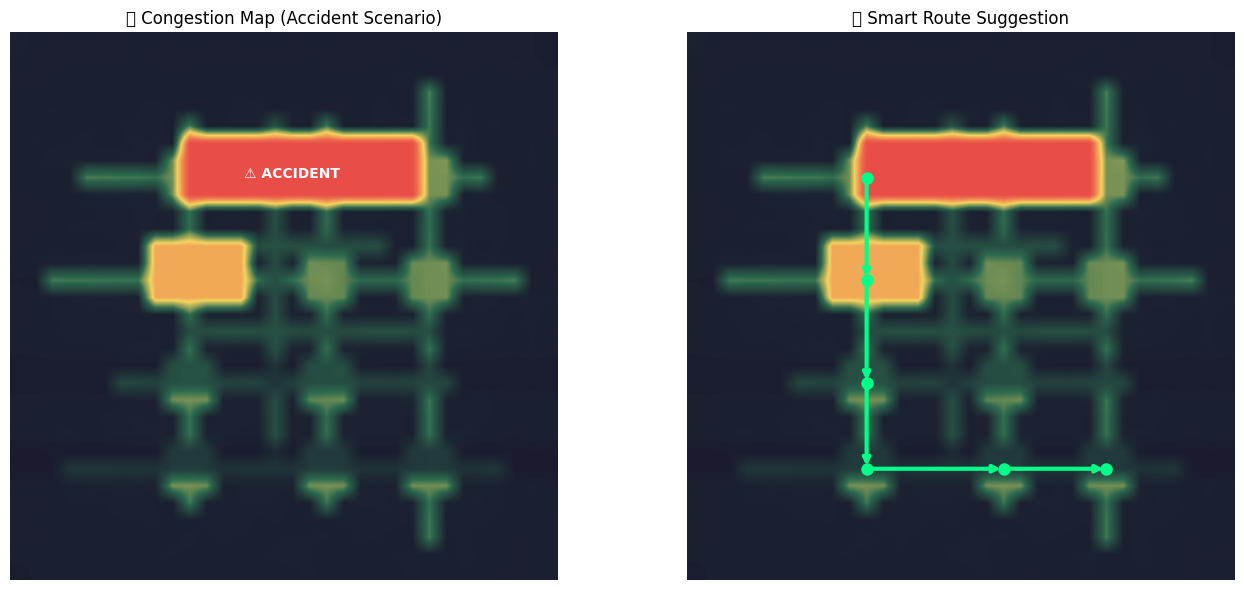


Saved to Drive!


In [15]:
# Create a realistic scenario: peak hour + accident on Neftchilar Ave
demo_congestion = pred[0].copy()

# Simulate accident on Neftchilar Ave (row 8)
demo_congestion[6:10, 10:24] = 0.9  # heavy jam
# Spillover to Babek Ave near Nizami
demo_congestion[12:16, 8:14] = 0.6

# Tbilisi and Bunyadov stay clear
demo_congestion[19:21, :] *= 0.5
demo_congestion[24:26, :] *= 0.3

print("SCENARIO: Accident on Neftchilar Ave + Peak Hour")
print(f"  Neftchilar congestion: {demo_congestion[8, 10:24].mean():.2f}")
print(f"  Babek congestion:      {demo_congestion[14, 10:18].mean():.2f}")
print(f"  Tbilisi congestion:    {demo_congestion[20, 10:18].mean():.2f}")
print(f"  Bunyadov congestion:   {demo_congestion[25, 10:18].mean():.2f}")

print("\n" + "=" * 60)
print("  🚨 SMART ROUTING — Accident + Peak Hour Scenario")
print("=" * 60)

test_routes = [
    ("Neftchilar/Nizami", "Neftchilar/Heydar"),
    ("Neftchilar/Nizami", "Bunyadov/Heydar"),
    ("Neftchilar/Heydar", "Tbilisi/Nizami"),
]

for start, end in test_routes:
    path_default, roads_default, _ = find_route(start, end, demo_congestion, use_congestion=False)
    cost_default = real_cost_of_path(path_default, demo_congestion)

    path_smart, roads_smart, cost_smart = find_route(start, end, demo_congestion, use_congestion=True)

    default_roads = " → ".join(dict.fromkeys(roads_default))
    smart_roads = " → ".join(dict.fromkeys(roads_smart))

    time_default = int(cost_default * 0.5)
    time_smart = int(cost_smart * 0.5)
    saved = time_default - time_smart

    print(f"\n📍 {start}  →  {end}")
    print(f"{'─' * 50}")
    print(f"  ❌ Shortest: {default_roads}")
    print(f"     Time: {time_default} min (congested!)")
    print(f"  ✅ Smart:   {smart_roads}")
    print(f"     Time: {time_smart} min")
    if saved > 0:
        print(f"  💡 Save ~{saved} min by avoiding Neftchilar Ave!")

# Visualize the scenario
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#1a1a2e', '#2d6a4f', '#f4d35e', '#ee6c4d', '#e63946']
cmap = LinearSegmentedColormap.from_list('traffic', colors, N=256)

axes[0].imshow(demo_congestion, cmap=cmap, vmin=0, vmax=1, interpolation='bilinear')
axes[0].set_title("🚨 Congestion Map (Accident Scenario)", fontsize=12)
axes[0].text(16, 8, "⚠ ACCIDENT", color='white', fontsize=10, ha='center', fontweight='bold')

axes[1].imshow(demo_congestion, cmap=cmap, vmin=0, vmax=1, interpolation='bilinear')
axes[1].set_title("✅ Smart Route Suggestion", fontsize=12)

# Draw smart route for first test case
path_smart, _, _ = find_route("Neftchilar/Nizami", "Bunyadov/Heydar", demo_congestion)
for i in range(len(path_smart)-1):
    r1, c1 = intersections[path_smart[i]]
    r2, c2 = intersections[path_smart[i+1]]
    axes[1].annotate("", xy=(c2, r2), xytext=(c1, r1),
                     arrowprops=dict(arrowstyle="->", color='#00ff88', lw=3))
    axes[1].plot(c1, r1, 'o', color='#00ff88', markersize=8)
axes[1].plot(c2, r2, 'o', color='#00ff88', markersize=8)

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/traffic_project/routing_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved to Drive!")